In [1]:
import pandas as pd
import numpy as np
import os

import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from madrigal.evaluate.predict import get_data_for_analysis, make_predictions, get_drug_specific_scores
from madrigal.evaluate.metrics import get_metrics
from madrigal.utils import BASE_DIR
%matplotlib inline

DDI_PATH = BASE_DIR + 'processed_data/drug_combination_data/DrugBank/'
VIEWS_PATH = BASE_DIR + 'processed_data/drug_features/'

No CUDA runtime is found, using CUDA_HOME='$CUDA_HOME/'


['str', 'kg', 'cv']


In [2]:
raw_drugbank_df = pd.read_pickle('../raw_drugbank_df.pkl')
print(raw_drugbank_df.columns)

drug_metadata = pd.read_pickle(os.path.join(VIEWS_PATH, "drug_metadata_ddi.pkl"))
drug_metadata["view_str"] = 1

drug_metadata = drug_metadata.merge(
    raw_drugbank_df[["drugbank_id", "drug_type", "description", "indication", "moa", "toxicity", "atc_codes", "targets", "enzymes", "carriers", "transporters"]].rename(columns={"indication":"indication_drugbank"}), 
    left_on='node_id', right_on='drugbank_id', how='left'
).drop(columns=[
    col for col in drug_metadata.columns 
    if col.endswith("_sig_id") or col.endswith("_pert_dose") or col.endswith("_sig_id") or (col in {"inchi_key", "drugbank_id", "cv_dose"})
])

# confirm that "best" drug pairs don't have adverse ddi effects with another dataset
db_polypharmacy = pd.read_csv(DDI_PATH + 'drugbank_ddi_directed.tsv', index_col=None)[["label_indexed", "drug_index_1", "drug_index_2"]]
db_polypharmacy = pd.concat([
    db_polypharmacy,
    db_polypharmacy.rename(columns={"drug_index_1":"drug_index_2", "drug_index_2":"drug_index_1"})
], axis=0).drop_duplicates()

organs_csv = pd.read_csv('../drugbank_ddi_organs.csv', sep='\t')
organ_class_mapping = organs_csv.set_index("ddi_class").to_dict()["organ"]  # ddi_class : organ


Index(['drugbank_id', 'drug_name', 'drug_type', 'smiles', 'inchikey',
       'description', 'indication', 'pharmacodynamics', 'moa', 'absorption',
       'metabolism', 'toxicity', 'atc_codes', 'classifications', 'targets',
       'enzymes', 'carriers', 'transporters'],
      dtype='object')


In [3]:
data_source = "DrugBank"
split_method = "split_by_drugs_random"
repeat = None
checkpoint = "madrigal_seed42"  # DrugBank, split_by_drugs_random
epoch = None
kg_encoder = 'hgt'
checkpoint_dir = BASE_DIR + f'model_output/{data_source}/{split_method}/{checkpoint}/'
if epoch is None:
    ckpt = checkpoint_dir + "best_model.pt"
else:
    ckpt = checkpoint_dir + f"checkpoint_{epoch}.pt"
finetune_mode = "str_str+random_sample"

In [4]:
# configs for str ablation
str_ablation_checkpoint = "structure_only_no_pretrain_seed42"  # DrugBank, split-by-drugs-random

kg_encoder = "hgt"
str_ablation_checkpoint_dir = BASE_DIR + f"model_output/{data_source}/{split_method}/{str_ablation_checkpoint}/"
if epoch is None:
    str_ablation_ckpt = str_ablation_checkpoint_dir + "best_model.pt"
else:
    str_ablation_ckpt = str_ablation_checkpoint_dir + f"checkpoint_{epoch}.pt"
str_ablation_finetune_mode = "ablation_str_str"
device = torch.device("cpu")

str_ablation_train_batch, str_ablation_val_batches, str_ablation_test_batches, str_ablation_label_map = get_data_for_analysis(
    data_source=data_source, kg_encoder=kg_encoder, split_method=split_method, repeat=repeat, 
    path_base = BASE_DIR + "processed_data/", checkpoint_dir=str_ablation_checkpoint_dir
)

# test between
str_ablation_batch = str_ablation_test_batches[0]

In [5]:
# configs for no pretraining ablation
no_pretrain_ablation_checkpoint = "no_pretrain_seed42"  # DrugBank, split-by-drugs-random

kg_encoder = "hgt"
no_pretrain_ablation_checkpoint_dir = BASE_DIR + f"model_output/{data_source}/{split_method}/{no_pretrain_ablation_checkpoint}/"
if epoch is None:
    no_pretrain_ablation_ckpt = no_pretrain_ablation_checkpoint_dir + "best_model.pt"
else:
    no_pretrain_ablation_ckpt = no_pretrain_ablation_checkpoint_dir + f"checkpoint_{epoch}.pt"
no_pretrain_ablation_finetune_mode = "str_str+random_sample"
device = torch.device("cpu")

no_pretrain_ablation_train_batch, no_pretrain_ablation_val_batches, no_pretrain_ablation_test_batches, no_pretrain_ablation_label_map = get_data_for_analysis(
    data_source=data_source, kg_encoder=kg_encoder, split_method=split_method, repeat=repeat, 
    path_base=BASE_DIR+"processed_data/", checkpoint_dir=no_pretrain_ablation_checkpoint_dir
)

# test between
no_pretrain_ablation_batch = no_pretrain_ablation_test_batches[0]

In [6]:
# test between
train_batch, val_batches, test_batches, label_map = get_data_for_analysis(
    data_source=data_source, kg_encoder=kg_encoder, split_method=split_method, repeat=repeat, 
    path_base=BASE_DIR+"processed_data/", checkpoint_dir=checkpoint_dir
)
batch = test_batches[0]

ddi_labels = batch['edge_indices']['label']
ddi_pos_neg_samples = batch['edge_indices']['pos_neg'].float()
true_ddis = ddi_pos_neg_samples
label_map_valid = np.array(label_map)[np.unique(ddi_labels)]

In [7]:
# generate scores and label-stratified metrics for full model
eval_type = 'full_full'  # 'str_full', 'str+tx_full', 'str+cv+tx_full'

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
pred_ddis = make_predictions(ckpt, batch, eval_type, finetune_mode, device)  # expect to see two printings of missing keys, the first one containing "covariates_embeddings.0.weight"

metrics, pos_samples = get_metrics(
    pred_ddis.numpy(), 
    true_ddis.numpy(), 
    ddi_labels.numpy(), 
    k=50, 
    task='multiclass', 
    average=None, 
    logger=None, 
    verbose=False, 
)

test_between_scores = pd.DataFrame({
    "label_ind":np.unique(ddi_labels),
    'label':label_map_valid, 
    'specificity':metrics['specificity'], 
    'npv':metrics['npv'], 
    'auprc':metrics['auprc'], 
    'auroc':metrics['auroc'], 
    'num_pos_sample':pos_samples.astype(int)
}).sort_values('auprc', ascending=False)

Using pretrained structure encoder
Using pretrained KG encoder
Using pretrained cv encoder
Using pretrained TX encoder
INCOMP_KEYS (make sure these contain what you expected):
%s {   'Missing keys': [   'covariates_embeddings.0.weight'],
    'Unexpected_keys': [   ]}


{'Missing keys': [], 'Unexpected_keys': []}


In [8]:
# drug-stratified scores
eval_type = "str_full"

all_metrics, between_test_drugs = get_drug_specific_scores(checkpoint_dir, batch, eval_type, finetune_mode, device, mode="test_between")
str_ablation_all_metrics, between_test_drugs = get_drug_specific_scores(str_ablation_checkpoint_dir, str_ablation_batch, eval_type, str_ablation_finetune_mode, device, mode='test_between')
no_pretrain_ablation_all_metrics, between_test_drugs = get_drug_specific_scores(no_pretrain_ablation_checkpoint_dir, no_pretrain_ablation_batch, eval_type, no_pretrain_ablation_finetune_mode, device, mode='test_between')

Using pretrained structure encoder
Using pretrained KG encoder
Using pretrained cv encoder
Using pretrained TX encoder
INCOMP_KEYS (make sure these contain what you expected):
%s {   'Missing keys': [   'covariates_embeddings.0.weight'],
    'Unexpected_keys': [   ]}


{'Missing keys': [], 'Unexpected_keys': []}


Using pretrained structure encoder
Using pretrained KG encoder
Using pretrained cv encoder
Using pretrained TX encoder
INCOMP_KEYS (make sure these contain what you expected):
%s {   'Missing keys': [   'covariates_embeddings.0.weight'],
    'Unexpected_keys': [   ]}


{'Missing keys': [], 'Unexpected_keys': []}


Using pretrained structure encoder
Using pretrained KG encoder
Using pretrained cv encoder
Using pretrained TX encoder
INCOMP_KEYS (make sure these contain what you expected):
%s {   'Missing keys': [   'covariates_embeddings.0.weight'],
    'Unexpected_keys': [   ]}
{'Missing keys': [], 'Unexpected_keys': []}


In [9]:
# drug-stratified scores
eval_type = "full_full"

all_metrics_full_full, _ = get_drug_specific_scores(checkpoint_dir, batch, eval_type, finetune_mode, device, mode="test_between")
str_ablation_all_metrics_full_full, _ = get_drug_specific_scores(str_ablation_checkpoint_dir, str_ablation_batch, eval_type, str_ablation_finetune_mode, device, mode='test_between')
no_pretrain_ablation_all_metrics_full_full, _ = get_drug_specific_scores(no_pretrain_ablation_checkpoint_dir, no_pretrain_ablation_batch, eval_type, no_pretrain_ablation_finetune_mode, device, mode='test_between')

Using pretrained structure encoder
Using pretrained KG encoder
Using pretrained cv encoder
Using pretrained TX encoder
INCOMP_KEYS (make sure these contain what you expected):
%s {   'Missing keys': [   'covariates_embeddings.0.weight'],
    'Unexpected_keys': [   ]}
{'Missing keys': [], 'Unexpected_keys': []}


Using pretrained structure encoder
Using pretrained KG encoder
Using pretrained cv encoder
Using pretrained TX encoder
INCOMP_KEYS (make sure these contain what you expected):
%s {   'Missing keys': [   'covariates_embeddings.0.weight'],
    'Unexpected_keys': [   ]}


{'Missing keys': [], 'Unexpected_keys': []}


Using pretrained structure encoder
Using pretrained KG encoder
Using pretrained cv encoder
Using pretrained TX encoder
INCOMP_KEYS (make sure these contain what you expected):
%s {   'Missing keys': [   'covariates_embeddings.0.weight'],
    'Unexpected_keys': [   ]}
{'Missing keys': [], 'Unexpected_keys': []}


# Examine label-wise DDI predictions

Examine best and worst DDIs.

In [ ]:
num_samples_in_classes = (db_polypharmacy["label_indexed"].value_counts() / 2).astype(int).to_dict()
test_between_scores["organ"] = test_between_scores["label"].apply(lambda ddi_class: organ_class_mapping[ddi_class])
test_between_scores["num_all_pos_sample"] = test_between_scores["label_ind"].apply(lambda ind: num_samples_in_classes[ind])
test_between_scores[test_between_scores['num_pos_sample'] >= 5].head(10)

,label_ind,label,specificity,npv,auprc,auroc,num_pos_sample,organ,num_all_pos_sample
105,114,"ototoxicity, increase",1.000000,1.000000,1.000000,1.000000,6,others/general,27
31,34,"cardiac arrhythmia, CNS stimulation, increase",1.000000,0.833333,1.000000,1.000000,5,heart,23
55,58,"gastrointestinal ulceration, gastrointestinal ...",0.964286,1.000000,1.000000,1.000000,14,gastrointestinal,59
139,150,"ulceration, increase",1.000000,1.000000,1.000000,1.000000,14,gastrointestinal,59
113,123,"renal failure, hypotension, increase",1.000000,1.000000,1.000000,1.000000,7,kidney,40
86,94,"myelosuppression, anemia, severe leukopenia, i...",0.928571,1.000000,1.000000,1.000000,7,blood,27
50,53,"fluid retention, increase",0.946667,1.000000,0.997788,0.998933,75,kidney,288
32,35,"cardiac arrhythmia, cardiotoxicity, increase",0.919355,1.000000,0.997004,0.998439,31,heart,157
134,145,"tendinopathy, increase",0.982363,0.996422,0.996564,0.998371,567,others/general,1855
140,151,"urinary retention, increase",1.000000,0.945455,0.995558,0.997781,26,urinary,119


In [ ]:
test_between_scores[test_between_scores['num_pos_sample'] >= 5].tail(10).iloc[::-1]

,label_ind,label,specificity,npv,auprc,auroc,num_pos_sample,organ,num_all_pos_sample
87,95,"myelosuppression, increase",0.930412,0.681132,0.393493,0.474094,194,blood,418
81,89,"liver damage, increase",0.882550,0.762319,0.586228,0.727625,149,liver,400
42,45,"effectiveness as a diagnostic agent, decrease",0.903226,0.745011,0.608223,0.658891,186,others/general,684
44,47,"excretion rate, decrease | serum level, increase",0.954304,0.741023,0.609336,0.641738,50551,"liver, kidney",157241
34,37,"cardiodepressant, increase",0.963415,0.766990,0.624466,0.620761,41,heart,103
107,116,"photosensitizing, increase",0.884615,0.741935,0.634797,0.727811,13,others/general,63
33,36,"cardiac arrhythmia, increase",0.964093,0.755806,0.638959,0.648673,3899,heart,11628
132,143,"tachycardia, drowsiness, increase",0.972900,0.774542,0.676757,0.680059,369,"heart, others/general",979
59,63,"hyperkalemia, increase",0.971378,0.770049,0.687021,0.699766,5066,"kidney, heart",15329
127,138,"serum level of the active metabolites, increase",0.898810,0.782383,0.692818,0.771755,84,others/general,369


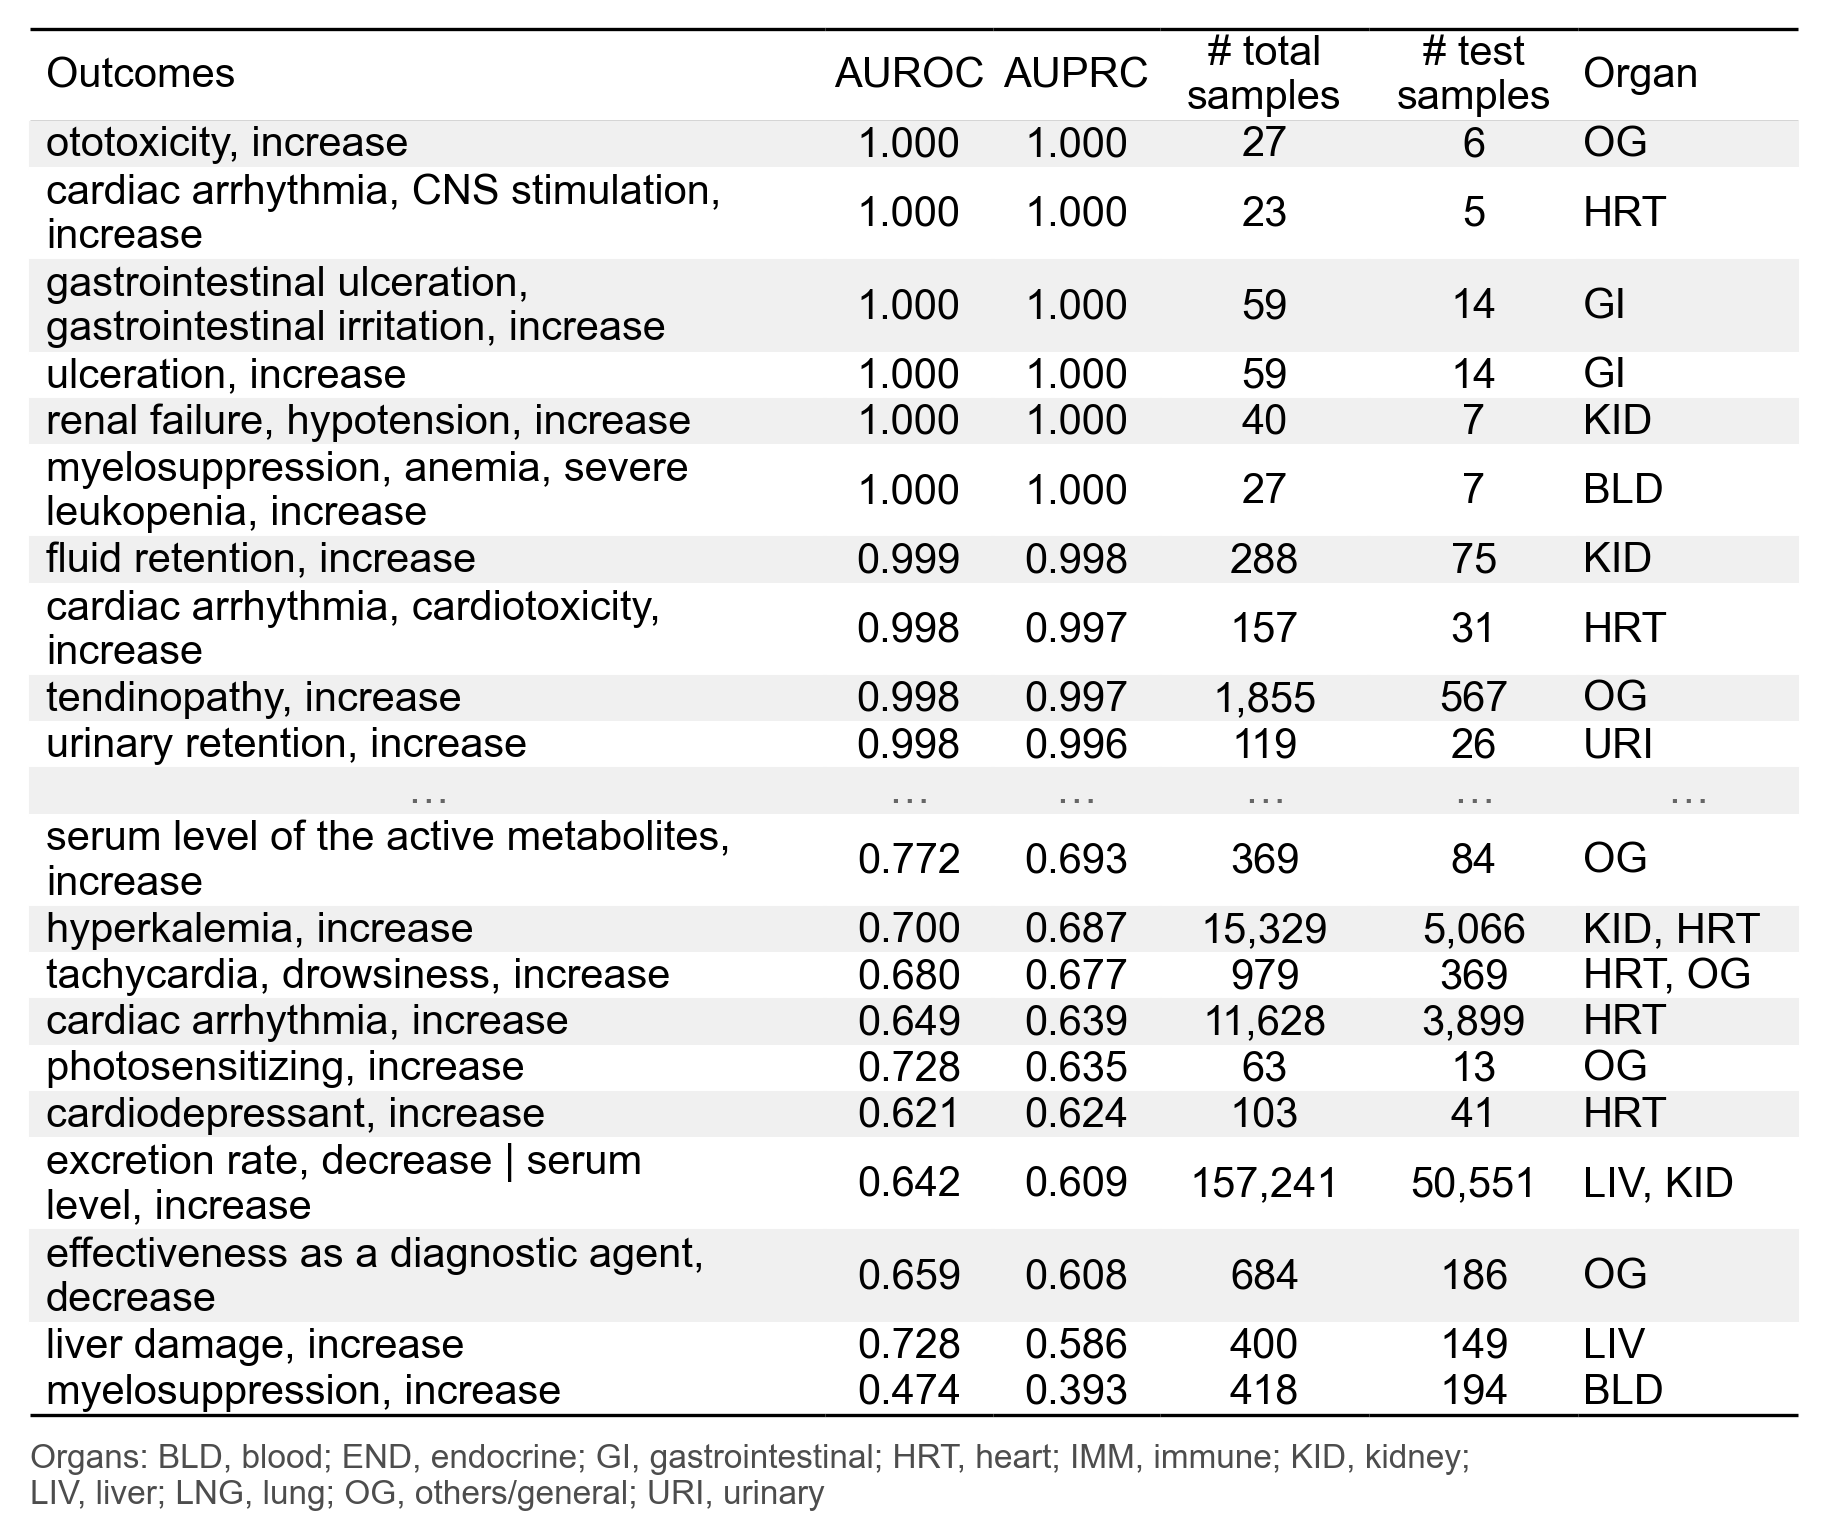

In [15]:
# supplementary table: 10 best- and 10 worst-predicted DDI outcomes (>= 5 positive test samples)
import textwrap
from matplotlib import font_manager as fm

arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

ORGAN_ACRONYMS = {  # covers every organ in drugbank_ddi_organs.csv
    "blood": "BLD",
    "endocrine": "END",
    "gastrointestinal": "GI",
    "heart": "HRT",
    "immune": "IMM",
    "kidney": "KID",
    "liver": "LIV",
    "lung": "LNG",
    "others/general": "OG",
    "urinary": "URI",
}

def _abbrev_organ(organ):
    return ", ".join(ORGAN_ACRONYMS[part.strip()] for part in organ.split(","))

n_show = 10
table_source = test_between_scores[test_between_scores["num_pos_sample"] >= 5]  # already sorted by AUPRC, descending

def _format_rows(df):
    return [
        [
            textwrap.fill(row["label"], 38),
            f"{row['auroc']:.3f}",
            f"{row['auprc']:.3f}",
            f"{row['num_all_pos_sample']:,}",
            f"{row['num_pos_sample']:,}",
            _abbrev_organ(row["organ"]),
        ]
        for _, row in df.iterrows()
    ]

columns = ["Outcomes", "AUROC", "AUPRC", "# total\nsamples", "# test\nsamples", "Organ"]
col_widths = [0.38, 0.08, 0.08, 0.10, 0.10, 0.105]  # Organ fits the longest shown acronym string ("KID, HRT")
cell_text = _format_rows(table_source.head(n_show)) + [["…"] * len(columns)] + _format_rows(table_source.tail(n_show))

# each row is as tall as its most-wrapped cell
row_lines = [max(str(cell).count("\n") + 1 for cell in row) for row in [columns] + cell_text]
total_lines = sum(row_lines)

fig, ax = plt.subplots(figsize=(9 * sum(col_widths), 0.2 * total_lines), dpi=300)
ax.axis("off")
# bbox=[0, 0, 1, 1] makes the table span the axes exactly, so no slack is left around it
table = ax.table(cellText=cell_text, colLabels=columns, colWidths=col_widths, cellLoc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)

n_data_rows = len(cell_text)
ellipsis_ind = n_show + 1  # +1 for the header row
for (r, c), cell in table.get_celld().items():
    cell.set_height(row_lines[r] / total_lines)
    cell.PAD = 0.02
    # left-align the text columns, keep the numeric ones centered
    cell.set_text_props(ha="left" if c in {0, 5} and r != ellipsis_ind else "center")
    # banding: a cell only paints its facecolor along a visible path, so match the edge color to the fill
    facecolor = "0.94" if 1 <= r <= n_data_rows and r % 2 == 1 else "white"
    cell.set_facecolor(facecolor)
    cell.visible_edges = "closed"
    cell.set_edgecolor(facecolor)
    cell.set_linewidth(0.5)
    if r == 0:  # header, ruled above and below (booktabs style)
        cell.get_text().set_weight("bold")
        cell.visible_edges = "TB"
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
    elif r == ellipsis_ind:
        cell.get_text().set_color("0.4")

# bottom rule, drawn over the last row's banding
for c in range(len(columns)):
    bottom_cell = table[n_data_rows, c]
    bottom_cell.visible_edges = "B"
    bottom_cell.set_edgecolor("black")
    bottom_cell.set_linewidth(0.8)

organ_legend = "; ".join(f"{acronym}, {organ}" for organ, acronym in ORGAN_ACRONYMS.items())
ax.text(0, -0.02, textwrap.fill("Organs: " + organ_legend, 95), transform=ax.transAxes, fontsize=8, color="0.3", va="top")

plt.savefig("./fig2_supp_table_best_worst_ddi_outcomes.svg", format="svg", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()

# Examine drug-stratified DDI predictions

## Performance vs max structural similarity with any train drug

In [10]:
metric_name = "auprc"
train_drugs = train_batch['head']['drugs'].tolist()
train_sms = drug_metadata['canonical_smiles'].values[train_drugs]
test_sms = drug_metadata['canonical_smiles'].values[between_test_drugs]

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
between_test_max_sim_scores = []
between_test_highest_5_mean_sim_scores = []

train_mols = [AllChem.AddHs(Chem.MolFromSmiles(sm)) for sm in train_sms]
train_fps = [AllChem.GetMorganFingerprintAsBitVect(x, 2, nBits=256) for x in train_mols]
test_mols = [AllChem.AddHs(Chem.MolFromSmiles(sm)) for sm in test_sms]
test_fps = [AllChem.GetMorganFingerprintAsBitVect(x, 2, nBits=256) for x in test_mols]

# tanimoto similarity
# https://stackoverflow.com/questions/51681659/how-to-use-rdkit-to-calculte-molecular-fingerprint-and-similarity-of-a-list-of-s
# BulkDiceSimilarity, BulkTanimotoSimilarity
for fp in test_fps:
    sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)  # max similarity
    between_test_max_sim_scores.append(np.max(sims))
    between_test_highest_5_mean_sim_scores.append(np.mean(np.partition(sims, -5)[-5:]))

In [11]:
drug_metadata.loc[between_test_drugs[(np.array(between_test_max_sim_scores) < .25) & (np.array(all_metrics['auprc']) < np.array(str_ablation_all_metrics['auprc']))]][
    ["canonical_smiles", "node_name"] + [col for col in drug_metadata.columns if col.startswith("view_")]
]

,canonical_smiles,node_name,view_tx_mcf7,view_tx_npc,view_tx_hela,view_tx_hec108,view_tx_thp1,view_tx_ha1e,view_tx_ht29,view_tx_hepg2,...,view_tx_hcc515,view_tx_yapc,view_tx_pc3,view_tx_vcap,view_tx_a375,view_tx_asc,view_tx_huvec,view_cv,view_kg,view_str
1175,O=[Zn],Zinc oxide,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1289,[N-]=[N+]=O,Nitrous oxide,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1315,[Pt],Platinum,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1826,S=[Mo](=S)([S-])[S-],Tetrathiomolybdate,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2077,[Ca+2].[N-]=C=[N-],Calcium carbimide,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3102,[Xe],Xenon,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


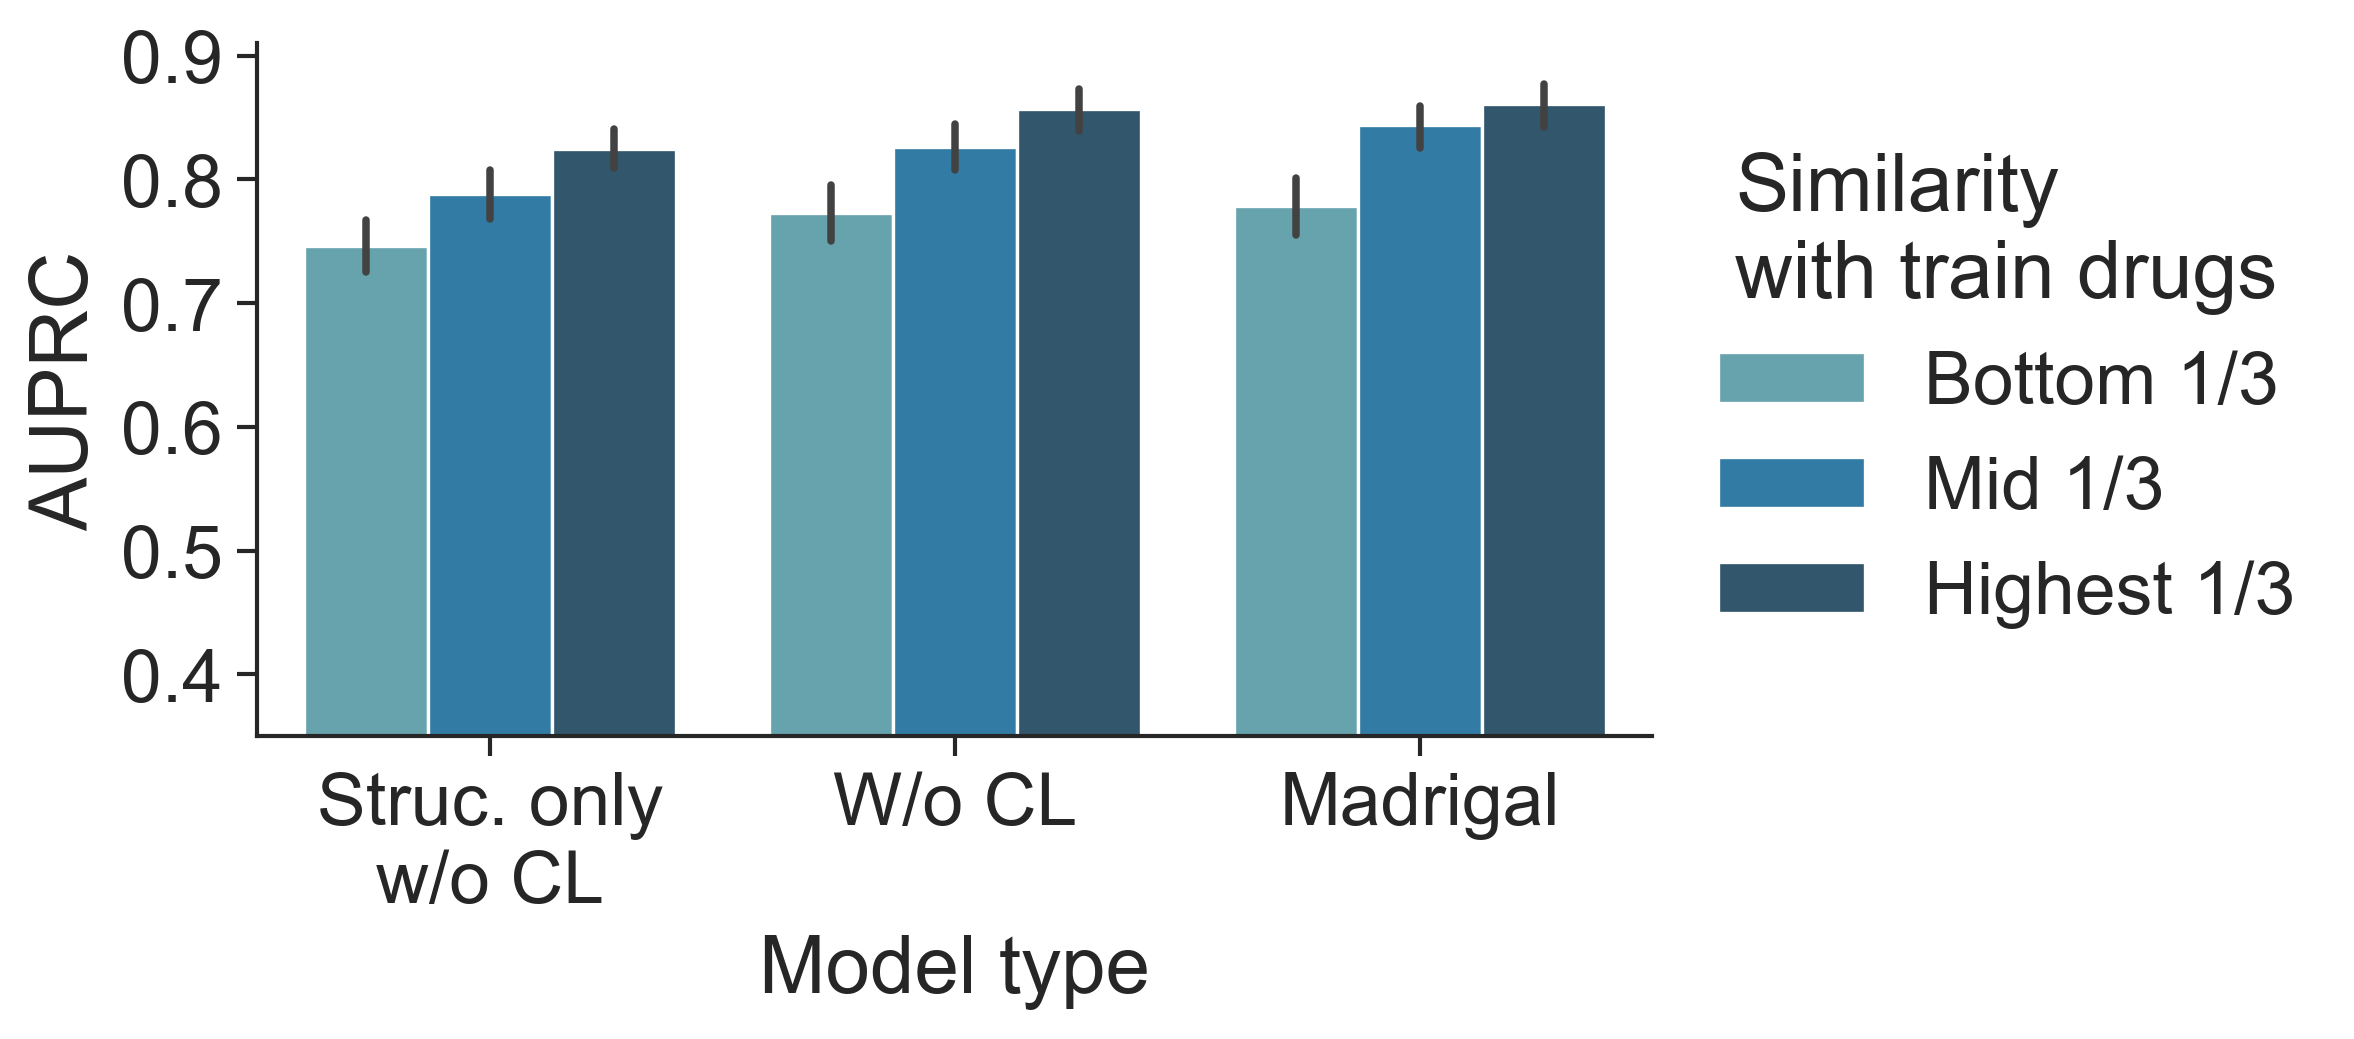

In [21]:

num_bins = 3
sim_groups = np.zeros_like(between_test_highest_5_mean_sim_scores)
sim_group_labels = np.array(["aaaaaaaaa"] * len(between_test_highest_5_mean_sim_scores))  # np string array requires to specify maximum length
for lo, hi in zip(np.linspace(0,1,num_bins+1)[:-1], np.linspace(0,1,num_bins+1)[1:]):
    if lo == 0:
        valid_indices = np.where((np.array(between_test_highest_5_mean_sim_scores) >= lo) & (np.array(between_test_highest_5_mean_sim_scores) <= hi))[0]
    else:
        valid_indices = np.where((np.array(between_test_highest_5_mean_sim_scores) > lo) & (np.array(between_test_highest_5_mean_sim_scores) <= hi))[0]
    sim_groups[valid_indices] = (lo+hi) / 2
    sim_group_labels[valid_indices] = f"{lo:.2f}-{hi:.2f}"
    
plot_data = pd.DataFrame({
    'sim': between_test_highest_5_mean_sim_scores + between_test_highest_5_mean_sim_scores + between_test_highest_5_mean_sim_scores,
    'Similarity': sim_group_labels.tolist() * 3,
    'AUPRC': str_ablation_all_metrics['auprc'] + no_pretrain_ablation_all_metrics["auprc"] + all_metrics['auprc'],
    'Model type': ['Struc. only\nw/o CL'] * len(sim_groups) + ["W/o CL"] * len(sim_groups) + ['Madrigal'] * len(sim_groups),
})

# if group by proportion instead of absolute values
plot_data["Similarity"] = ["Highest 1/3" if bin_id in {2} else ("Bottom 1/3" if bin_id in {0} else "Mid 1/3")
                                    for bin_id in pd.qcut(plot_data["sim"], 3, labels=False).values]
plot_data["Similarity"] = plot_data["Similarity"].astype(
    pd.api.types.CategoricalDtype(categories=["Bottom 1/3", "Mid 1/3", "Highest 1/3"], ordered=True)
)

from matplotlib import font_manager as fm
arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.figure(figsize=(6, 3), dpi=300)
sns.set(style="ticks", font_scale=2, context="paper")

sns.barplot(
    plot_data, hue='Similarity', y='AUPRC', x='Model type', palette="YlGnBu_d",
)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title="Similarity\nwith train drugs")  # highest 5 mean
plt.ylim(0.35, 0.91)
plt.yticks(np.arange(0.4, 0.91, 0.1))
sns.despine()

plt.savefig("./fig2_test_highest_5_mean_str_sim_with_train_bottleneck.svg", format="svg", dpi=300)
plt.show()

In [15]:
from scipy.stats import mannwhitneyu

print(mannwhitneyu(
    plot_data[(plot_data["Model type"] == "Struc. only\nw/o CL") & (plot_data["Similarity"] == "Bottom 1/3")]["AUPRC"].values,
    plot_data[(plot_data["Model type"] == "Struc. only\nw/o CL") & (plot_data["Similarity"] == "Mid 1/3")]["AUPRC"].values,
    alternative="two-sided",
))
print(mannwhitneyu(
    plot_data[(plot_data["Model type"] == "Struc. only\nw/o CL") & (plot_data["Similarity"] == "Mid 1/3")]["AUPRC"].values,
    plot_data[(plot_data["Model type"] == "Struc. only\nw/o CL") & (plot_data["Similarity"] == "Highest 1/3")]["AUPRC"].values,
    alternative="two-sided",
))
print()
print(mannwhitneyu(
    plot_data[(plot_data["Model type"] == "W/o CL") & (plot_data["Similarity"] == "Bottom 1/3")]["AUPRC"].values,
    plot_data[(plot_data["Model type"] == "W/o CL") & (plot_data["Similarity"] == "Mid 1/3")]["AUPRC"].values,
    alternative="two-sided",
))
print(mannwhitneyu(
    plot_data[(plot_data["Model type"] == "W/o CL") & (plot_data["Similarity"] == "Mid 1/3")]["AUPRC"].values,
    plot_data[(plot_data["Model type"] == "W/o CL") & (plot_data["Similarity"] == "Highest 1/3")]["AUPRC"].values,
    alternative="two-sided",
))
print()
print(mannwhitneyu(
    plot_data[(plot_data["Model type"] == "Madrigal") & (plot_data["Similarity"] == "Bottom 1/3")]["AUPRC"].values,
    plot_data[(plot_data["Model type"] == "Madrigal") & (plot_data["Similarity"] == "Mid 1/3")]["AUPRC"].values,
    alternative="two-sided",
))
print(mannwhitneyu(
    plot_data[(plot_data["Model type"] == "Madrigal") & (plot_data["Similarity"] == "Mid 1/3")]["AUPRC"].values,
    plot_data[(plot_data["Model type"] == "Madrigal") & (plot_data["Similarity"] == "Highest 1/3")]["AUPRC"].values,
    alternative="two-sided",
))

MannwhitneyuResult(statistic=24811.5, pvalue=0.0036672778831261296)
MannwhitneyuResult(statistic=24993.0, pvalue=0.006582923433556982)

MannwhitneyuResult(statistic=23857.0, pvalue=0.00042208919520167866)
MannwhitneyuResult(statistic=25012.0, pvalue=0.006833384014867027)

MannwhitneyuResult(statistic=23668.5, pvalue=0.00026385721726451643)
MannwhitneyuResult(statistic=26309.5, pvalue=0.06304438479070086)


## Performance vs target profile similarity with any train drug

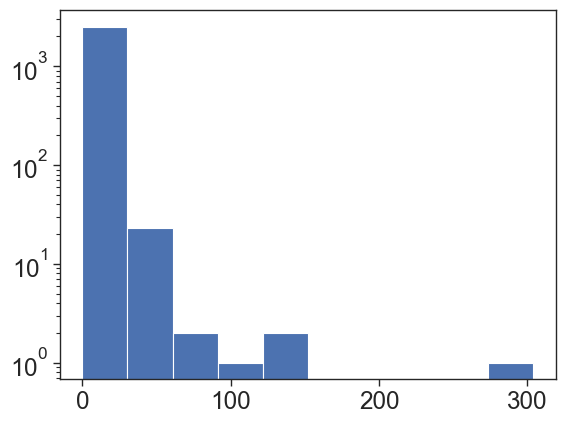

In [13]:
metric_name = "auprc"
train_targets = drug_metadata["targets"].values[train_drugs]
between_test_targets = drug_metadata["targets"].values[between_test_drugs]

plt.hist(list(map(len, train_targets)), ec="white")
plt.yscale("log")

In [14]:
# remove drugs that have too many targets
to_remove_train_ind = [drug_ind for drug_ind, targets in zip(train_drugs, train_targets) if len(targets) > 100]
to_remove_test_ind = [drug_ind for drug_ind, targets in zip(between_test_drugs.tolist(), between_test_targets) if len(targets) > 100]

between_test_target_sim_scores = []

# jaccard similarity
for targets_1 in between_test_targets:
    sims = []
    if len(targets_1) == 0:
        between_test_target_sim_scores.append(sims)
        continue
    for targets_2 in train_targets:
        if len(targets_2) == 0:
            continue
        else:
            sims.append(len(set(targets_1) & set(targets_2)) / len(set(targets_1) | set(targets_2)))
    between_test_target_sim_scores.append(sims)

In [15]:
between_test_target_sims_max = np.array([np.max(sims) if len(sims) > 0 else np.nan for sims in between_test_target_sim_scores])
between_test_target_sims_highest_5_mean = np.array([np.mean(np.partition(sims, -5)[-5:]) if len(sims) > 0 else np.nan for sims in between_test_target_sim_scores])
between_test_target_sims_prop_geq_05 = np.array([(np.array(sims) >= 0.5).sum() / len(sims) if len(sims) > 0 else np.nan for sims in between_test_target_sim_scores])

/tmp/ipykernel_1203179/2711836492.py:24: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  ax = sns.pointplot(


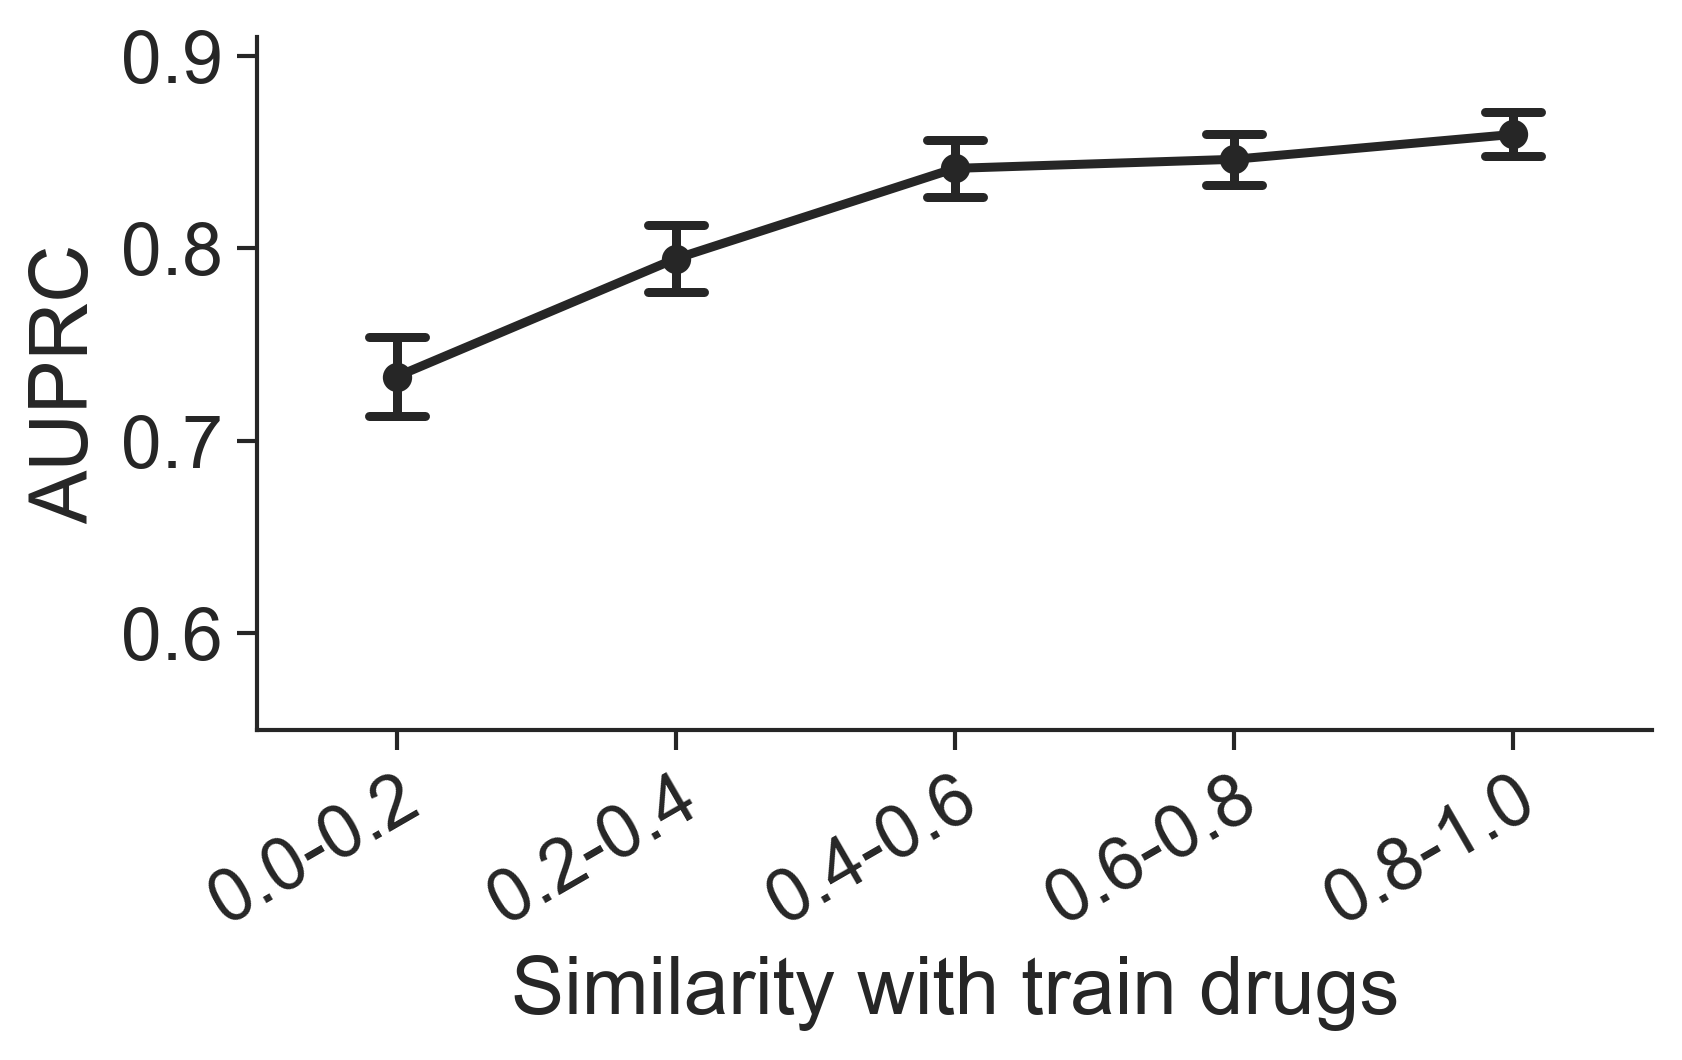

In [22]:
num_bins = 5
median_scores = []
sim_groups = np.zeros_like(between_test_target_sims_highest_5_mean)
sim_group_labels = np.array(["aaaaaaaaa"] * len(between_test_target_sims_highest_5_mean))  # np string array requires to specify maximum length
for lo, hi in zip(np.linspace(0, 1, num_bins+1)[:-1], np.linspace(0, 1, num_bins+1)[1:]):
    if lo == 0:
        valid_indices = np.where((np.array(between_test_target_sims_highest_5_mean) >= lo) & (np.array(between_test_target_sims_highest_5_mean) <= hi))[0]
    else:
        valid_indices = np.where((np.array(between_test_target_sims_highest_5_mean) > lo) & (np.array(between_test_target_sims_highest_5_mean) <= hi))[0]
    sim_groups[valid_indices] = (lo+hi) / 2
    sim_group_labels[valid_indices] = f"{lo:.1f}-{hi:.1f}"
    
plot_data = pd.DataFrame({
    'sim': between_test_target_sims_highest_5_mean.tolist() + between_test_target_sims_highest_5_mean.tolist(),
    'similarity_group': sim_group_labels.tolist() * 2,
    'auprc': all_metrics['auprc'] + str_ablation_all_metrics['auprc'],
    'type': ['full'] * len(sim_groups) + ['structure-only'] * len(sim_groups)
})
plot_data = plot_data[~plot_data["sim"].isna()]

plt.figure(figsize=(6, 3), dpi=300)
sns.set(style="ticks", font_scale=2, context="paper")

ax = sns.pointplot(
    plot_data[plot_data["type"] == "full"], x='similarity_group', y='auprc', hue='type', c="cornflowerblue",
    capsize=.2, errorbar="se", order=sorted(plot_data["similarity_group"].unique()), 
    color="black", 
)
ax.get_legend().remove()
plt.ylabel("AUPRC")
plt.xlabel("Similarity with train drugs")
plt.ylim(0.55, 0.91)
plt.yticks(np.arange(0.6, 0.91, 0.1))
sns.despine()
plt.xticks(rotation=30, ha="right", rotation_mode="anchor")

plt.savefig("./fig2_test_highest_5_mean_target_sim_with_train_bottleneck.svg", format="svg", dpi=300)
plt.show()

In [20]:
from scipy.stats import mannwhitneyu

print(mannwhitneyu(
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.0-0.2")]["auprc"].values,
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.2-0.4")]["auprc"].values
))
print(mannwhitneyu(
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.2-0.4")]["auprc"].values,
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.4-0.6")]["auprc"].values
))
print(mannwhitneyu(
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.4-0.6")]["auprc"].values,
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.6-0.8")]["auprc"].values,
))
print(mannwhitneyu(
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.6-0.8")]["auprc"].values,
    plot_data[(plot_data["type"] == "full") & (plot_data["similarity_group"] == "0.8-1.0")]["auprc"].values
))

MannwhitneyuResult(statistic=2303.5, pvalue=0.011881219625089538)
MannwhitneyuResult(statistic=2579.0, pvalue=0.05313235157146324)
MannwhitneyuResult(statistic=2544.0, pvalue=0.9661780526805064)
MannwhitneyuResult(statistic=3631.0, pvalue=0.2283571327272056)
